In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import scipy.ndimage as ndimage
import glob, os, shutil, cv2, json, sys
from tqdm import tqdm

In [ ]:
IMG_PATH  = '/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/patches_1200'

In [ ]:
def getFiles(path, limit=None, shuffle=False):
    target = sorted([os.path.abspath(f) for f in glob.glob(os.path.join(path, '*'))])
    if shuffle:
        np.random.shuffle(target)     
    return target[:limit]

def setFolder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)

def getDAT(path):
    return np.fromfile(path, dtype=np.float32).reshape((128, 128, 128))

# CONVERTENDO IMAGENS

0.5024785 0.5028546 0.5026281 4.258365e-05


 showing index 0


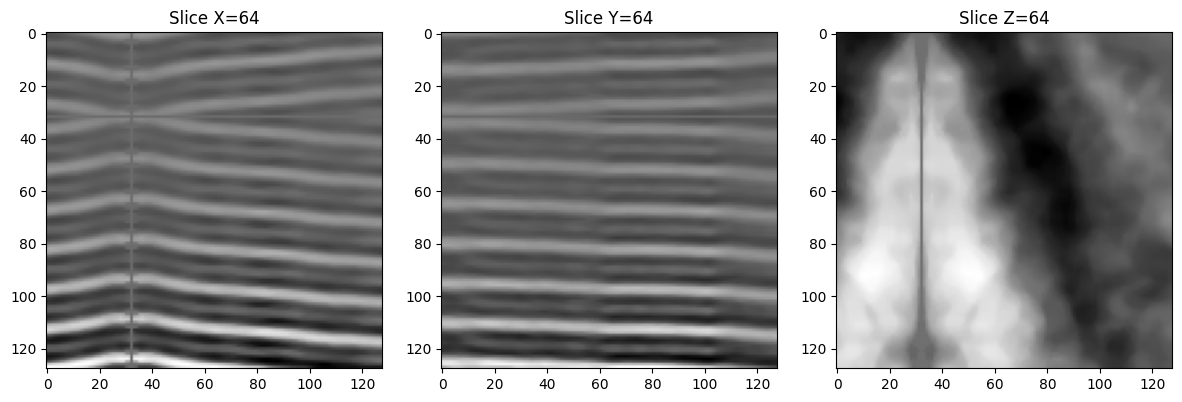

0.5024785 0.50283855 0.5026275 3.9993734e-05


 showing index 1


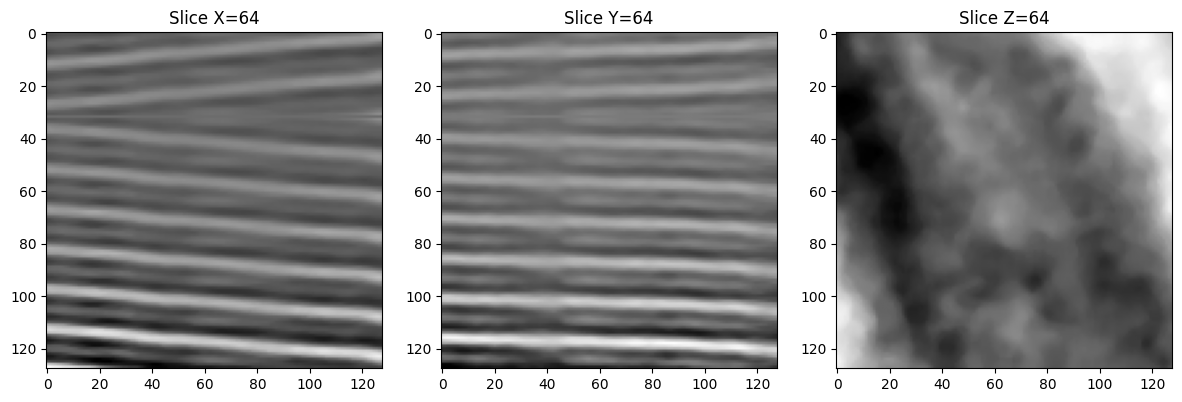

0.50248545 0.5028056 0.5026292 3.9528844e-05


 showing index 2


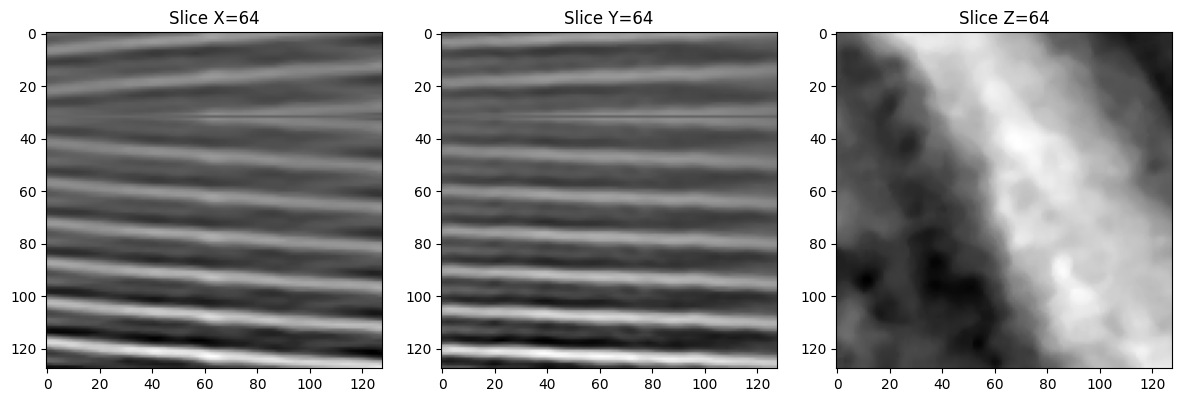

0.50250757 0.50280404 0.5026291 3.8355443e-05


 showing index 3


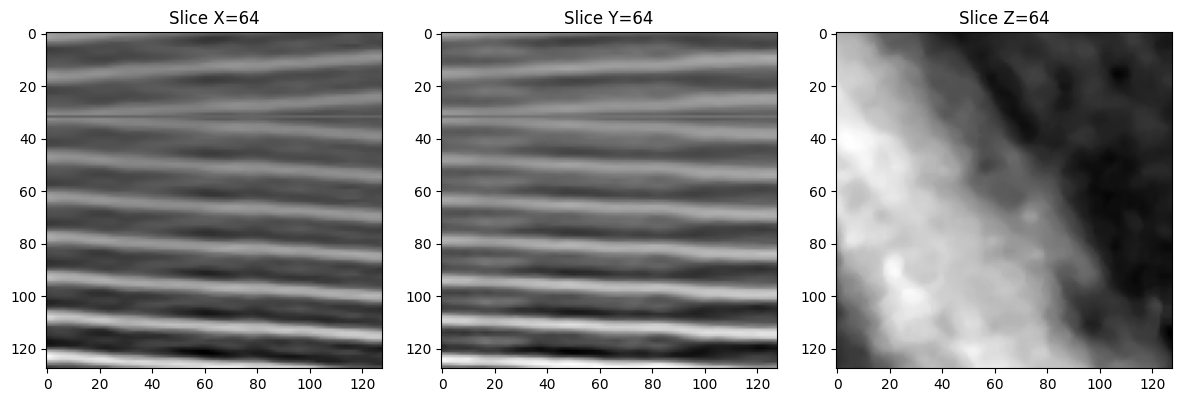

0.50250757 0.50279653 0.50262773 3.562198e-05


 showing index 4


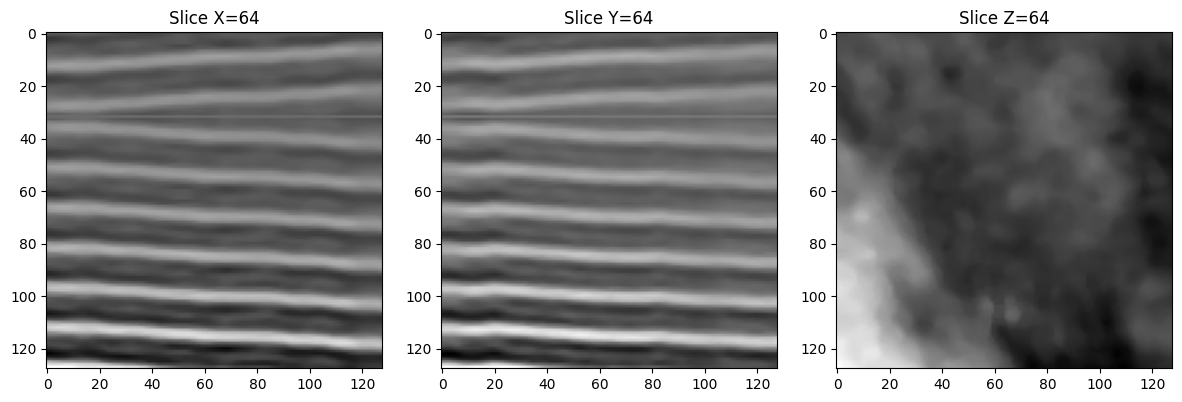

In [ ]:
def showTile(img, mask=False):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    mid_x = img.shape[0] // 2
    mid_y = img.shape[1] // 2
    mid_z = img.shape[2] // 2

    slices = [
        img[mid_x, :, :],  # Plano YZ (Corte ao longo do eixo X)
        img[:, mid_y, :],  # Plano XZ (Corte ao longo do eixo Y)
        img[:, :, mid_z]   # Plano XY (Corte ao longo do eixo Z)
    ]

    slices[0] = np.array(slices[0])
    arr_y = np.array(slices[1])
    arr_z = np.array(slices[2])
    slices[1] = np.rot90(arr_z, -1)
    slices[2] = arr_y

    cmap_config = ListedColormap(['black', 'red', 'green', 'blue']) if mask else 'gray'
    vmin, vmax  = (0, 3) if mask else (None, None)
    titles = [f'Slice X={mid_x}', f'Slice Y={mid_y}', f'Slice Z={mid_z}']
    
    for i, ax in enumerate(axes):
        ax.imshow(slices[i], cmap=cmap_config, vmin=vmin, vmax=vmax)
        ax.set_title(titles[i])
    
    plt.tight_layout()
    plt.show()


for i, img_path in enumerate(getFiles(IMG_PATH)):
    if i == 5:
        break
    
    img = getDAT(img_path)
    print(np.min(img), np.max(img), np.mean(img), np.std(img))

    print(f'\n\n showing index {i}')
    showTile(img, mask=False)

In [ ]:
df = pd.DataFrame()
df['img_path'] = [file for file in getFiles(IMG_PATH)]
df['shape']    = [(128, 128, 128) for path in df.img_path]
df['min']  = [np.min(np.load(path))  for path in df.img_path]
df['max']  = [np.max(np.load(path))  for path in df.img_path]
df['mean'] = [np.mean(np.load(path)) for path in df.img_path]
df['std']  = [np.std(np.load(path))  for path in df.img_path]

print(df.img_path.iloc[2])
df

NameError: name 'images' is not defined

In [7]:
df.to_csv('../DataBase.csv', index=None)
df

,img_path,shape
0,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
1,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
2,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
3,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
4,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
...,...,...
905,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
906,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
907,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
908,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
